In [1]:
import pandas as pd

In [10]:
df = pd.read_csv("./data/BTC-USD_1h_20250101_20260101.csv.gz", index_col="Datetime")
display(df)

,Open,High,Low,Close,Volume
Datetime,,,,,
2025-01-01 00:00:00,93396.031250,94256.054688,93312.703125,94256.054688,0
2025-01-01 01:00:00,94214.007812,94214.007812,93420.578125,93429.906250,0
2025-01-01 02:00:00,93420.054688,93854.312500,93420.054688,93849.250000,0
2025-01-01 03:00:00,93866.445312,93866.445312,93551.687500,93614.742188,0
2025-01-01 04:00:00,93632.890625,93632.890625,93430.546875,93465.992188,0
...,...,...,...,...,...
2025-12-31 19:00:00,87561.851562,87712.132812,87420.515625,87455.484375,296370176
2025-12-31 20:00:00,87419.890625,87534.906250,87141.007812,87534.906250,7612416
2025-12-31 21:00:00,87531.632812,87692.289062,87531.632812,87637.195312,1113237504


# 2.

ANYCOLOR株式会社（にじさんじ）5032.T

カバー株式会社（ホロライブ）5253.T

[*********************100%***********************]  1 of 1 completed


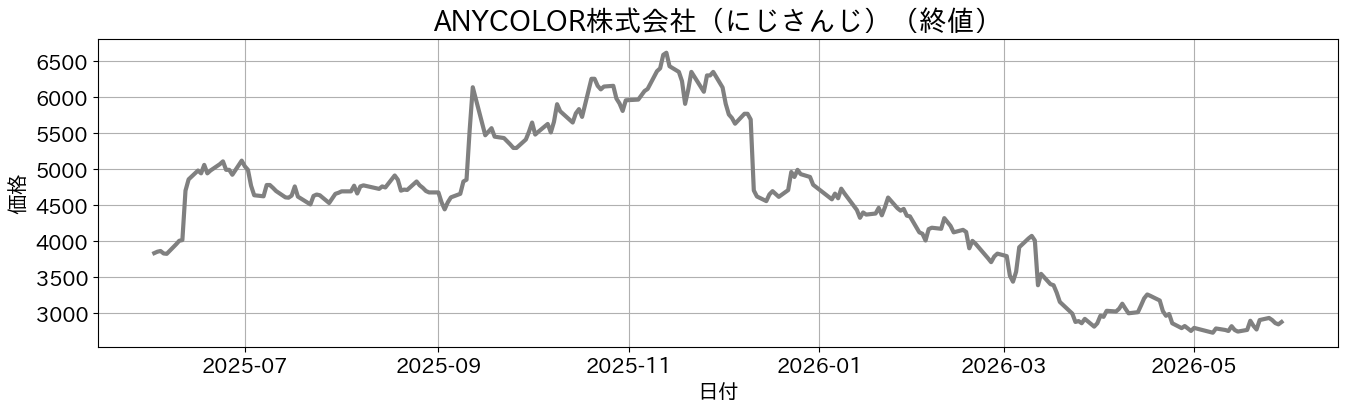

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt # グラフ作成
import matplotlib_fontja
%matplotlib inline

code2com_name = {"5032.T":"ANYCOLOR株式会社（にじさんじ）", "5232.T":"カバー株式会社（ホロライブ）"}
# ------------------------------------------------------------------
# 検索設定
# ------------------------------------------------------------------
code  = "5032.T"
start = "2025-06-01"  # 開始日
end   = "2026-06-01"  # 終了日
# ------------------------------------------------------------------

# 株価データ取得
df = yf.download(code, start=start, end=end)

# MultiIndexの場合、1段目だけを列名にする
df.columns = df.columns.get_level_values(0)

# 列名のタイトル Price を削除
df.columns.name = None

# 列の順序を指定
df = df[["Open", "High", "Low", "Close", "Volume"]]

# 時系列を昇順に並び替え
df = df.sort_index()

# インデックスのDateを列に移動
df = df.reset_index()

# 曜日の追加
df["day_name"] = df["Date"].dt.day_name()

# display(df)


# グラフ作成前に設定するオプション
plt.figure(figsize=(16, 4)) # 図のサイズ（横×縦）

# グラフ作成(x軸、y軸、凡例タイトル、線幅、色を指定)
plt.plot(df["Date"], df["Close"] , linewidth = 3, color = 'gray') 

# 追加オプション
plt.title(f"{code2com_name[code]}（終値）", fontsize=20)              # グラフタイトル
plt.xlabel('日付',fontsize=15)            # x軸ラベル
plt.ylabel('価格（円）',fontsize=15)        # y軸ラベル
plt.xticks(fontsize=15)                   # x軸の目盛文字サイズ
plt.yticks(fontsize=15)                   # y軸の目盛文字サイズ
plt.grid()                                # 補助線追加

# グラフ表示
plt.show()

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


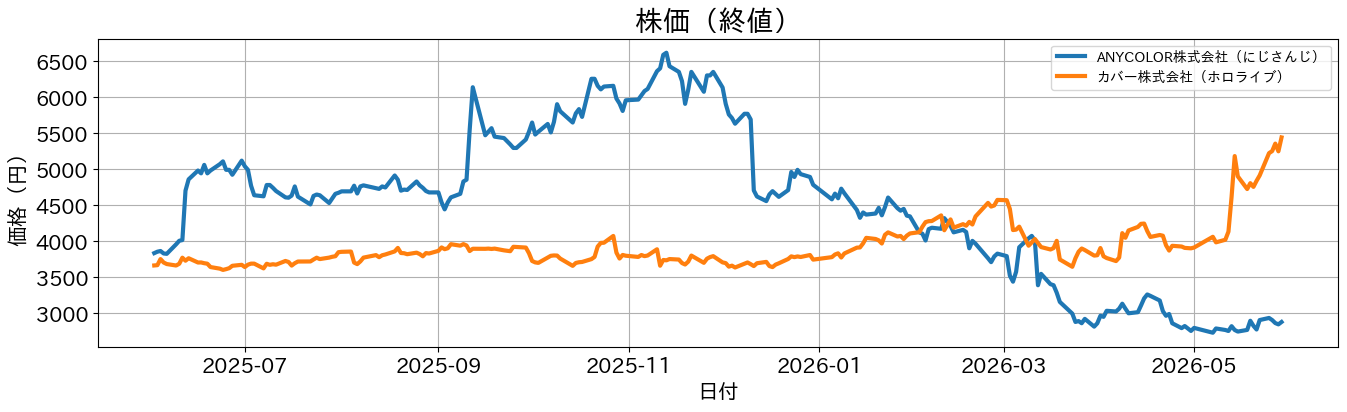

In [16]:
code2com_name = {"5032.T":"ANYCOLOR株式会社（にじさんじ）", "5232.T":"カバー株式会社（ホロライブ）"}

# グラフ作成前に設定するオプション
plt.figure(figsize=(16, 4)) # 図のサイズ（横×縦）

for k, v in code2com_name.items():
    # ------------------------------------------------------------------
    # 検索設定
    # ------------------------------------------------------------------
    code  = k
    start = "2025-06-01"  # 開始日
    end   = "2026-06-01"  # 終了日
    # ------------------------------------------------------------------

    # 株価データ取得
    df = yf.download(code, start=start, end=end)

    # MultiIndexの場合、1段目だけを列名にする
    df.columns = df.columns.get_level_values(0)

    # 列名のタイトル Price を削除
    df.columns.name = None

    # 列の順序を指定
    df = df[["Open", "High", "Low", "Close", "Volume"]]

    # 時系列を昇順に並び替え
    df = df.sort_index()

    # インデックスのDateを列に移動
    df = df.reset_index()

    # 曜日の追加
    df["day_name"] = df["Date"].dt.day_name()

    # display(df)

    # グラフ作成(x軸、y軸、凡例タイトル、線幅、色を指定)
    plt.plot(df["Date"], df["Close"], linewidth=3, label=f"{v}") 

# 追加オプション
plt.title("株価（終値）", fontsize=20)              # グラフタイトル
plt.xlabel('日付',fontsize=15)            # x軸ラベル
plt.ylabel('価格（円）',fontsize=15)        # y軸ラベル
plt.xticks(fontsize=15)                   # x軸の目盛文字サイズ
plt.yticks(fontsize=15)                   # y軸の目盛文字サイズ
plt.legend()
plt.grid()                                # 補助線追加

# グラフ表示
plt.show()